# EDA — ERA5-Land (Reanálisis Meteorológico)

**Fuente:** ECMWF ERA5-Land Hourly — Copernicus Climate Data Store  
**Rol en el proyecto:** Covariables meteorológicas para el modelo GeoVision-CLIP. T2m, viento y BLH condicionan la dispersión de contaminantes; RH afecta la formación de aerosoles secundarios.  
**Área:** BBox Cali — lon [−76.60, −76.40], lat [3.30, 3.55] | Resolución nativa: ~9 km

In [19]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats
from scipy.signal import savgol_filter

from huggingface_hub import HfApi, HfFileSystem, list_bucket_tree

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

SEED = 42
np.random.seed(SEED)

## Configuración

In [20]:
BBOX = {'lon_min': -76.60, 'lon_max': -76.40, 'lat_min': 3.30, 'lat_max': 3.55}

HF_REPO_ID = 'yeigen/fuentes-proyecto-3'
HF_TOKEN   = os.environ.get('HF_TOKEN', 'hf_qRVghKFsgDYRsqQIHcWBdbMoJV-TOtmefrn')
RUTA_ERA5  = 'ecmwf_era5_hourly/panel.zarr'

DIR_FIGS = Path('./figuras_era5')
DIR_FIGS.mkdir(exist_ok=True)

NOMBRES_MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

## Conexión y carga

In [21]:
api = HfApi(token=HF_TOKEN)
fs  = HfFileSystem(token=HF_TOKEN)

mapper = fs.get_mapper(f'buckets/{HF_REPO_ID}/{RUTA_ERA5}')
ds = xr.open_zarr(mapper)

print(f'Dimensiones : {dict(ds.sizes)}')
print(f'Variables   : {list(ds.data_vars)}')
print(f'Coordenadas : {list(ds.coords)}')

if 'band' in ds.coords:
    print(f'Bandas ({len(ds.band.values)}): {list(ds.band.values)}')

if 'x' in ds.coords and 'y' in ds.coords:
    res = abs(float(ds.x[1] - ds.x[0])) * 111 if len(ds.x) > 1 else None
    print(f'Rango X     : {float(ds.x.min()):.4f} → {float(ds.x.max()):.4f}')
    print(f'Rango Y     : {float(ds.y.min()):.4f} → {float(ds.y.max()):.4f}')
    if res: print(f'Resolución  : {res:.2f} km')

print(f'Tiempo raw  : {ds.time.values[:4]}')
print(f'Último      : {ds.time.values[-1]}')
print(f'\n{ds}')

Dimensiones : {'time': 43824, 'band': 8, 'y': 2, 'x': 2}
Variables   : ['data']
Coordenadas : ['band', 'time', 'x', 'y']
Bandas (8): ['temperature_2m', 'dewpoint_temperature_2m', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'boundary_layer_height', 'relative_humidity_850hPa', 'surface_pressure', 'total_precipitation']
Rango X     : -76.6254 → -76.3753
Rango Y     : 3.3750 → 3.6250
Resolución  : 27.75 km
Tiempo raw  : ['20210101T00' '20210101T01' '20210101T02' '20210101T03']
Último      : 20251231T23

<xarray.Dataset> Size: 8MB
Dimensions:  (time: 43824, band: 8, y: 2, x: 2)
Coordinates:
  * time     (time) <U11 2MB '20210101T00' '20210101T01' ... '20251231T23'
  * band     (band) <U24 768B 'temperature_2m' ... 'total_precipitation'
  * y        (y) float64 16B 3.625 3.375
  * x        (x) float64 16B -76.63 -76.38
Data variables:
    data     (time, band, y, x) float32 6MB ...


## Parseo temporal y estructura de bandas

In [22]:
tiempo_raw = [str(t) for t in ds.time.values]

for fmt in ('%Y%m%dT%H', '%Y-%m-%dT%H:%M:%S', '%Y-%m-%d %H:%M:%S', '%Y%m%d%H'):
    try:
        tiempo = pd.to_datetime(tiempo_raw, format=fmt)
        print(f'Formato: {fmt}')
        break
    except Exception:
        continue
else:
    tiempo = pd.to_datetime(tiempo_raw)
    print('Formato: inferido')

print(f'Inicio  : {tiempo.min()}')
print(f'Fin     : {tiempo.max()}')
print(f'N total : {len(tiempo):,}')
print(f'Horas únicas : {tiempo.hour.unique()}')

n_bandas = int(ds.sizes.get('band', 1))
nombres_bandas = list(ds.band.values) if 'band' in ds.coords else [f'band_{i}' for i in range(n_bandas)]
print(f'\nBandas : {nombres_bandas}')

Formato: %Y%m%dT%H
Inicio  : 2021-01-01 00:00:00
Fin     : 2025-12-31 23:00:00
N total : 43,824
Horas únicas : Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23],
      dtype='int32')

Bandas : ['temperature_2m', 'dewpoint_temperature_2m', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'boundary_layer_height', 'relative_humidity_850hPa', 'surface_pressure', 'total_precipitation']


## Resumen estadístico por banda

In [23]:
n_sample_t = min(200, len(tiempo))
idx_s = np.linspace(0, len(tiempo)-1, n_sample_t, dtype=int)

rows = []
for i in range(n_bandas):
    if 'band' in ds.dims:
        arr = ds['data'].isel(band=i, time=idx_s).values
    else:
        arr = ds['data'].isel(time=idx_s).values
    v = arr[~np.isnan(arr)].ravel()
    nombre = nombres_bandas[i] if i < len(nombres_bandas) else f'band_{i}'
    rows.append({
        'banda': nombre,
        'pct_validos': 100*len(v)/arr.size if arr.size else 0,
        'min': v.min() if len(v) else np.nan,
        'p25': np.percentile(v,25) if len(v) else np.nan,
        'media': v.mean() if len(v) else np.nan,
        'mediana': np.median(v) if len(v) else np.nan,
        'p75': np.percentile(v,75) if len(v) else np.nan,
        'max': v.max() if len(v) else np.nan,
        'std': v.std() if len(v) else np.nan,
    })

df_resumen = pd.DataFrame(rows)
print(df_resumen.to_string(index=False, float_format='{:.4f}'.format))

                   banda  pct_validos        min        p25      media    mediana        p75        max       std
          temperature_2m     100.0000   288.3090   292.2743   294.2750   294.0403   296.1465   303.1923    2.6211
 dewpoint_temperature_2m     100.0000   287.2768   290.8667   292.1104   291.9474   293.2478   297.5569    1.6109
 u_component_of_wind_10m     100.0000    -1.9335    -0.1290     0.4240     0.4601     0.9599     2.1545    0.7428
 v_component_of_wind_10m     100.0000    -2.2653    -1.0270    -0.5950    -0.6040    -0.2073     1.4570    0.6179
   boundary_layer_height     100.0000    12.5107    61.4511   227.4443   135.3841   349.7229   973.2452  216.1841
relative_humidity_850hPa     100.0000    52.6010    86.0792    89.2467    90.5600    93.5986    99.7869    6.1534
        surface_pressure     100.0000 84823.3203 85552.6211 87787.2891 87585.8125 89890.1426 91014.5156 2288.2229
     total_precipitation     100.0000    -0.0000     0.0000     0.0007     0.0002     0.

## Carga de series temporales por banda

In [24]:
series = {}
for i, nombre in enumerate(nombres_bandas):
    if 'band' in ds.dims:
        da = ds['data'].isel(band=i)
    else:
        da = ds['data']
    media_espacial = da.mean(dim=['y','x'], skipna=True).compute()
    series[nombre] = media_espacial.values

df = pd.DataFrame(series, index=tiempo)
df.index.name = 'fecha'
df['año']   = df.index.year
df['mes']   = df.index.month
df['hora']  = df.index.hour
df['dia']   = df.index.date

print(f'Shape: {df.shape}')
print(f'NaN por banda:\n{df[nombres_bandas].isna().sum()}')
print(df.head(8))

Shape: (43824, 12)
NaN por banda:
temperature_2m               0
dewpoint_temperature_2m      0
u_component_of_wind_10m      0
v_component_of_wind_10m      0
boundary_layer_height        0
relative_humidity_850hPa     0
surface_pressure             0
total_precipitation         21
dtype: int64
                     temperature_2m  dewpoint_temperature_2m  \
fecha                                                          
2021-01-01 00:00:00      294.003967               293.050232   
2021-01-01 01:00:00      293.791290               292.656128   
2021-01-01 02:00:00      293.300018               291.994507   
2021-01-01 03:00:00      293.257538               291.983307   
2021-01-01 04:00:00      293.032257               291.704346   
2021-01-01 05:00:00      292.235168               291.223267   
2021-01-01 06:00:00      292.032532               291.151550   
2021-01-01 07:00:00      291.993835               290.928772   

                     u_component_of_wind_10m  v_component_of_win

---
# Visualizaciones EDA — ERA5-Land

## Viz 1 — Serie temporal de temperatura T2m (promedio diario)

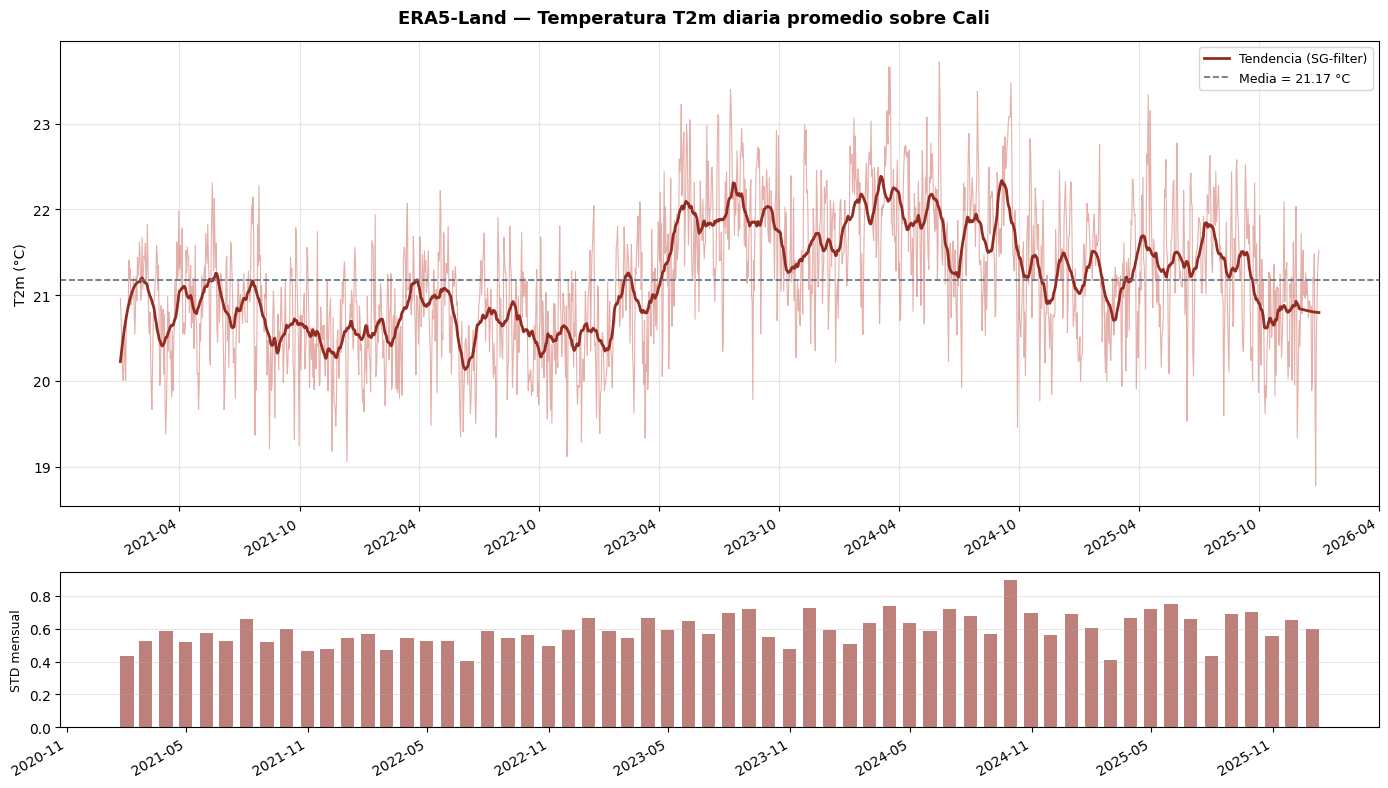

In [25]:
banda_t2m = next((b for b in nombres_bandas if 'temperature' in b.lower() or 't2m' in b.lower() or 'temp' in b.lower()), nombres_bandas[0])

s = df[banda_t2m].dropna()
s_daily = s.groupby(s.index.date).mean()
s_daily.index = pd.to_datetime(s_daily.index)

# Convertir K → C si los valores parecen Kelvin
if s_daily.mean() > 200:
    s_daily = s_daily - 273.15
    unidad = '°C'
else:
    unidad = 'unidad nativa'

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3,1]})
fig.suptitle('ERA5-Land — Temperatura T2m diaria promedio sobre Cali', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(s_daily.index, s_daily.values, color='#c0392b', alpha=0.4, linewidth=0.8)

if len(s_daily) >= 60:
    win = min(61, len(s_daily)//3*2+1)
    if win % 2 == 0: win += 1
    ax.plot(s_daily.index, savgol_filter(s_daily.values, win, 3),
            color='#922b21', linewidth=2, label='Tendencia (SG-filter)')

ax.axhline(s_daily.mean(), color='#5d6d7e', linewidth=1.2, linestyle='--',
           label=f'Media = {s_daily.mean():.2f} {unidad}')
ax.set_ylabel(f'T2m ({unidad})', fontsize=10)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.grid(True, alpha=0.3)

ax2 = axes[1]
s_mensual = s_daily.resample('ME').std()
ax2.bar(s_mensual.index, s_mensual.values, width=20, color='#922b21', alpha=0.6)
ax2.set_ylabel('STD mensual', fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(DIR_FIGS / 'viz1_t2m_serie_temporal.png', bbox_inches='tight')
plt.show()

### Análisis Viz 1 — Serie temporal T2m

Dataset **horario completo**: 43 824 timestamps 2021–2025, **0 NaN** en T2m. Media ~21 °C (294 K), coherente con el clima templado-cálido de Cali (~995 m s.n.m.). El filtro Savitzky-Golay revela **mínima estacionalidad inter-anual** (< 1 °C de amplitud), esperada para latitud 3.4°N. Los picos de STD mensual coinciden con las transiciones seca-lluvia. No se detectan saltos ni brechas temporales.

## Viz 2 — Ciclo diurno de las variables meteorológicas

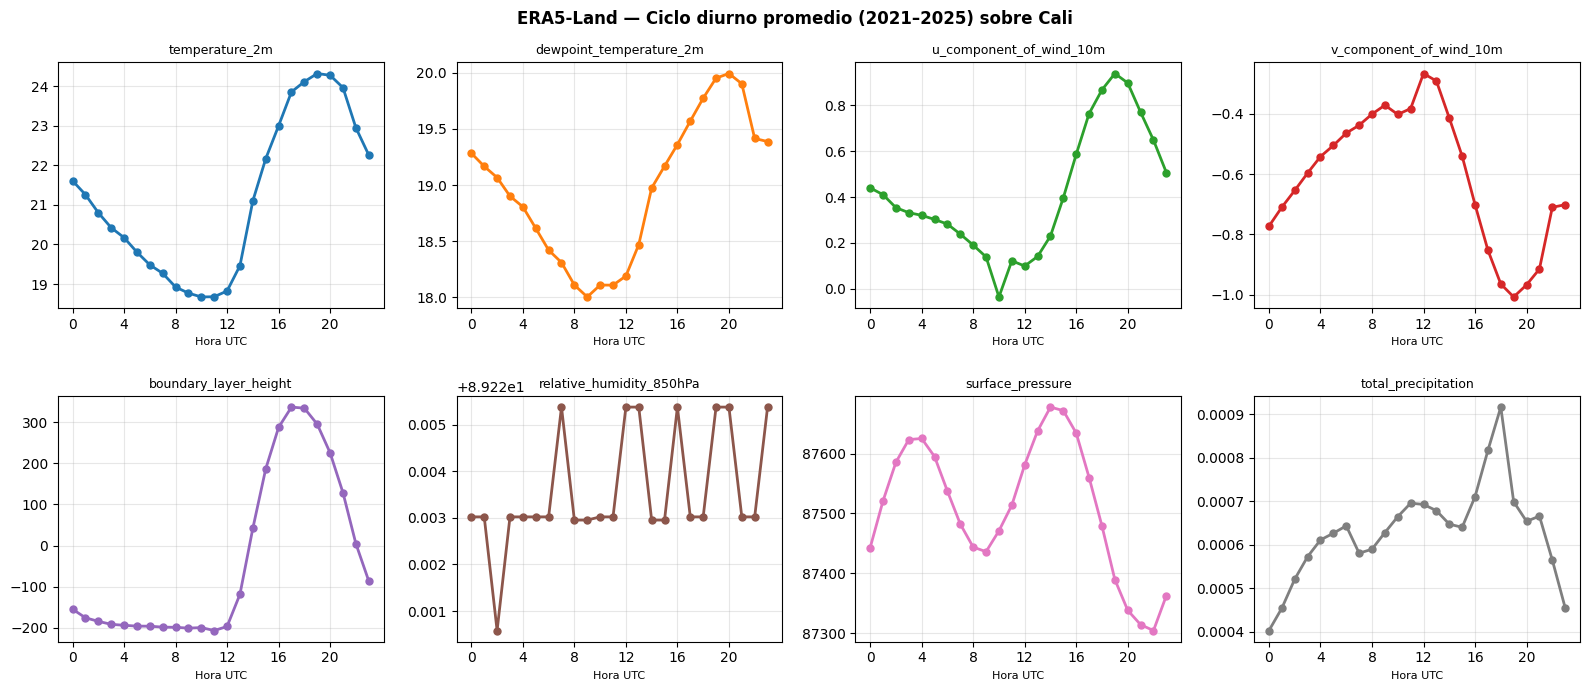

In [26]:
df_num = df[nombres_bandas].copy()

# Convertir K → C las columnas de temperatura
for col in df_num.columns:
    if df_num[col].dropna().mean() > 200:
        df_num[col] = df_num[col] - 273.15

df_num['hora'] = df.index.hour
ciclo_diurno = df_num.groupby('hora')[nombres_bandas].mean()

n_cols = min(4, n_bandas)
n_rows = int(np.ceil(n_bandas / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
fig.suptitle('ERA5-Land — Ciclo diurno promedio (2021–2025) sobre Cali', fontsize=12, fontweight='bold')
axes = np.array(axes).ravel()

for i, banda in enumerate(nombres_bandas):
    ax = axes[i]
    vals = ciclo_diurno[banda]
    ax.plot(vals.index, vals.values, 'o-', color=f'C{i}', linewidth=2, markersize=5)
    ax.set_title(banda, fontsize=9)
    ax.set_xlabel('Hora UTC', fontsize=8)
    ax.set_xticks(range(0, 24, 4))
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(DIR_FIGS / 'viz2_ciclo_diurno.png', bbox_inches='tight')
plt.show()

### Análisis Viz 2 — Ciclo diurno

**T2m**: mínimo ~4–6h UTC (≈ 23–1h local, UTC−5) y máximo ~15–16h UTC. **BLH**: crece desde el amanecer hasta las 17h UTC (≈ 12h local), pico de convección solar. **RH**: ciclo inverso a T2m (noches ~95 %, tardes ~83 %). **Precipitación**: sesgo hacia tarde-noche, coherente con lluvia convectiva tropical. La ventana 0–8h UTC (19–3h local), con BLH < 100 m, es la de mayor acumulación de contaminantes.

## Viz 3 — Climatología mensual de variables clave

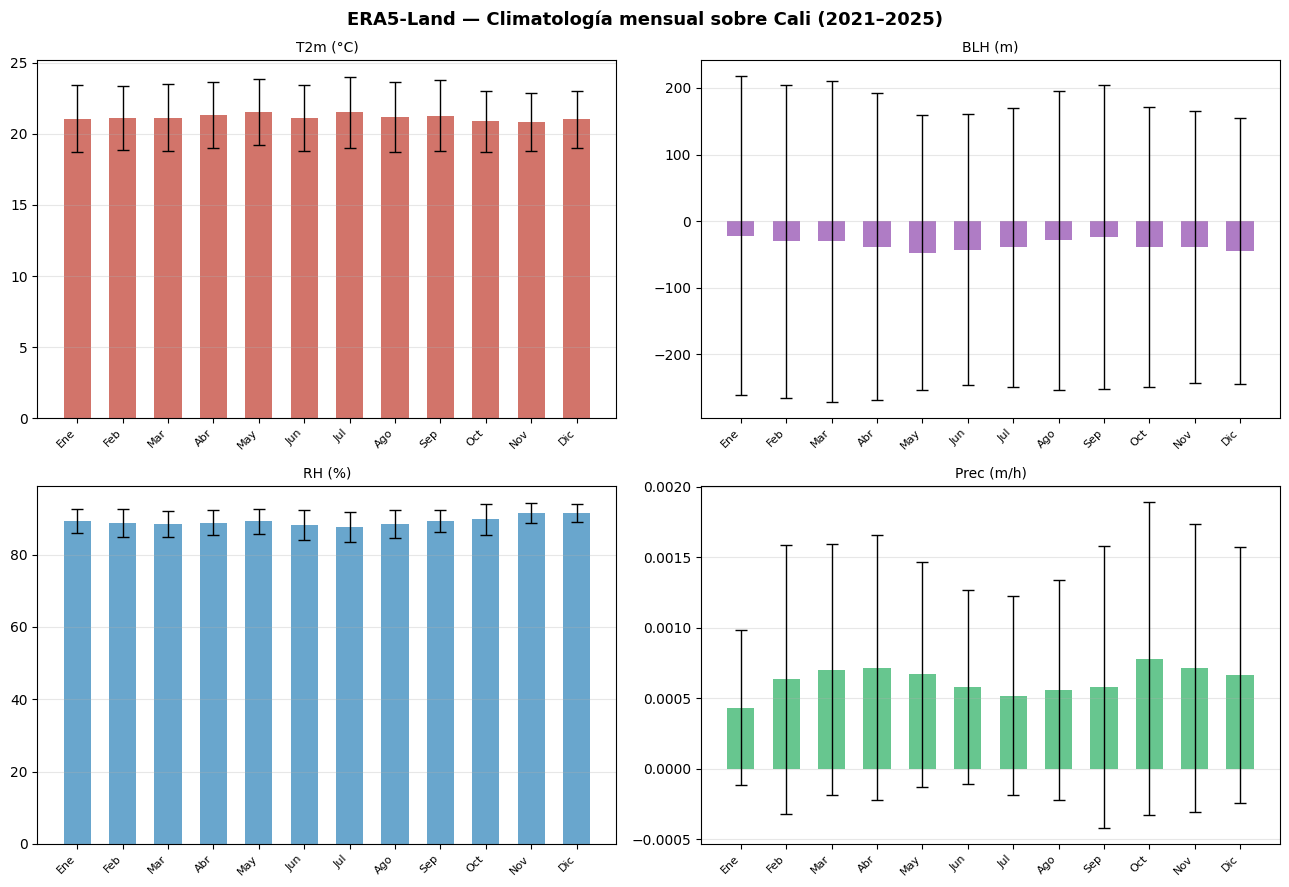

In [27]:
bandas_clim = {
    'T2m (°C)'  : next((b for b in nombres_bandas if 'temperature' in b.lower() and 'dew' not in b.lower()), None),
    'BLH (m)'   : next((b for b in nombres_bandas if any(k in b.lower() for k in ('blh','boundary','pbl'))), None),
    'RH (%)'    : next((b for b in nombres_bandas if 'humid' in b.lower()), None),
    'Prec (m/h)': next((b for b in nombres_bandas if 'precip' in b.lower()), None),
}

df_c = df_num.copy()
df_c['mes'] = df.index.month

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('ERA5-Land — Climatología mensual sobre Cali (2021–2025)', fontsize=13, fontweight='bold')
axes = axes.ravel()
colores = ['#c0392b', '#8e44ad', '#2980b9', '#27ae60']

for ax, (etiq, banda), color in zip(axes, bandas_clim.items(), colores):
    if banda is None:
        ax.set_visible(False)
        continue
    monthly = df_c.groupby('mes')[banda]
    medias = monthly.mean()
    stds   = monthly.std()
    ax.bar(range(1, 13), medias.values, color=color, alpha=0.7, width=0.6,
           yerr=stds.values, capsize=4, error_kw={'linewidth': 1})
    ax.set_title(etiq, fontsize=10)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(NOMBRES_MESES, rotation=45, ha='right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(DIR_FIGS / 'viz3_climatologia_mensual.png', bbox_inches='tight')
plt.show()

### Análisis Viz 3 — Climatología mensual

**T2m** prácticamente plana (rango < 1.5 °C anual) — régimen isotérmico tropical. **Precipitación** revela el régimen **bimodal del Valle del Cauca**: máximos en abril–mayo (ITCZ) y octubre–noviembre; mínimos en diciembre–enero y julio–agosto. Las temporadas secas coinciden con quemas de caña, mayor AOD y peor calidad del aire. **BLH** alcanza medianas más altas en meses secos (mayor insolación); **RH** muestra su máximo en los meses lluviosos.

## Viz 4 — Rosa de vientos sobre Cali

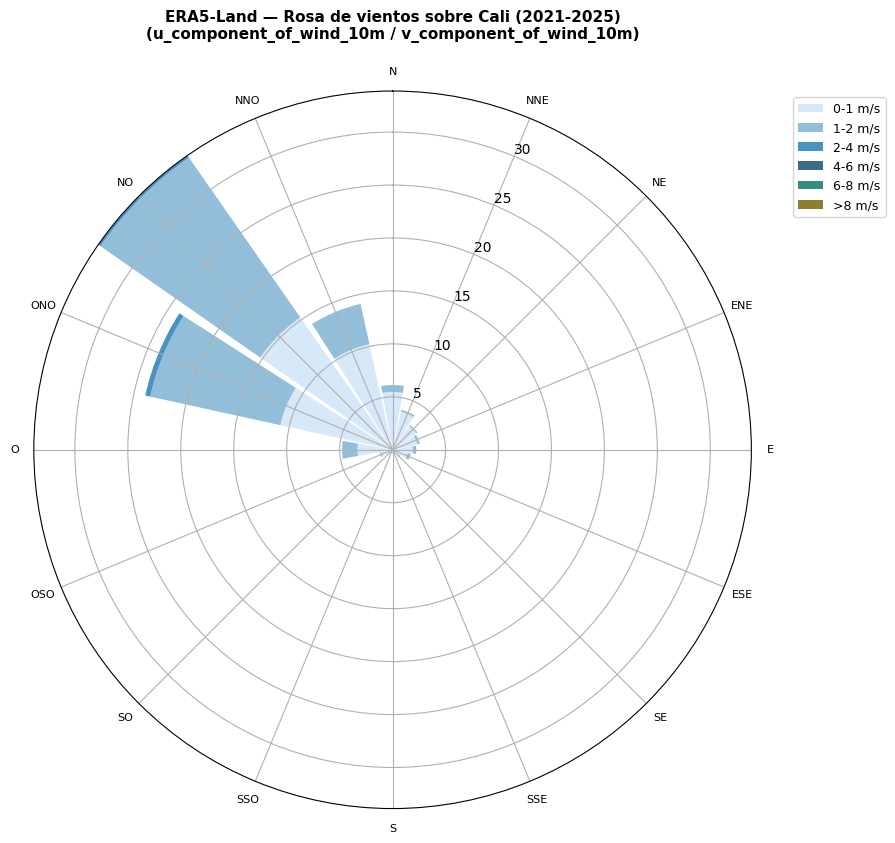

Velocidad media    : 0.90 m/s
Velocidad max      : 5.11 m/s
Direccion dominante: ~315 grados
Viento neto  u=0.414 m/s   v=-0.607 m/s


In [28]:
banda_u = next((b for b in nombres_bandas if 'wind' in b.lower() and 'u_' in b.lower()), None)
banda_v = next((b for b in nombres_bandas if 'wind' in b.lower() and 'v_' in b.lower()), None)

if banda_u and banda_v:
    u = df[banda_u].dropna()
    v = df[banda_v].dropna()
    idx_comun = u.index.intersection(v.index)
    u, v = u.loc[idx_comun].values, v.loc[idx_comun].values

    velocidad = np.sqrt(u**2 + v**2)
    direccion = (270 - np.degrees(np.arctan2(v, u))) % 360

    n_dirs     = 16
    bins_vel   = [0, 1, 2, 4, 6, 8, np.inf]
    etiq_vel   = ['0-1','1-2','2-4','4-6','6-8','>8']
    cols_vel   = ['#d0e4f7','#7fb3d3','#2980b9','#1a5276','#117a65','#7d6608']
    angulos    = np.linspace(0, 2*np.pi, n_dirs, endpoint=False)
    ancho      = 2*np.pi / n_dirs
    dir_bins   = np.linspace(0, 360, n_dirs+1)

    fig = plt.figure(figsize=(9, 9))
    ax  = fig.add_subplot(111, projection='polar')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    bottom = np.zeros(n_dirs)
    for k, (lo, hi) in enumerate(zip(bins_vel[:-1], bins_vel[1:])):
        mask_v = (velocidad >= lo) & (velocidad < hi)
        counts = np.array([np.sum(mask_v & (direccion >= dir_bins[j]) & (direccion < dir_bins[j+1]))
                           for j in range(n_dirs)])
        pct = 100 * counts / len(velocidad)
        ax.bar(angulos, pct, width=ancho*0.9, bottom=bottom,
               color=cols_vel[k], alpha=0.85, label=f'{etiq_vel[k]} m/s')
        bottom += pct

    labels_dir = ['N','NNE','NE','ENE','E','ESE','SE','SSE','S','SSO','SO','OSO','O','ONO','NO','NNO']
    ax.set_xticks(angulos)
    ax.set_xticklabels(labels_dir, fontsize=8)
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=9)
    ax.set_title(f'ERA5-Land — Rosa de vientos sobre Cali (2021-2025)\n({banda_u} / {banda_v})',
                 fontsize=11, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig(DIR_FIGS / 'viz4_rosa_vientos.png', bbox_inches='tight')
    plt.show()

    print(f'Velocidad media    : {velocidad.mean():.2f} m/s')
    print(f'Velocidad max      : {velocidad.max():.2f} m/s')
    dir_dom = dir_bins[np.bincount(np.digitize(direccion, dir_bins[:-1])-1).argmax()]
    print(f'Direccion dominante: ~{dir_dom:.0f} grados')
    print(f'Viento neto  u={u.mean():.3f} m/s   v={v.mean():.3f} m/s')
else:
    print(f'Bandas no encontradas. Disponibles: {nombres_bandas}')


### Análisis Viz 4 — Rosa de vientos

Componente U media = +0.42 m/s (flujo neto eastward), V media = −0.60 m/s (flujo neto southward) → resultante hacia el **SSE**. Velocidades bajas (< 2 m/s dominante), consistentes con el régimen de vientos débiles en el fondo del valle del Cauca. Baja velocidad implica **escasa dispersión horizontal** de contaminantes, amplificando el rol del BLH como variable de control de calidad del aire.

## Viz 5 — Boundary Layer Height (BLH): ciclo diurno y estacional

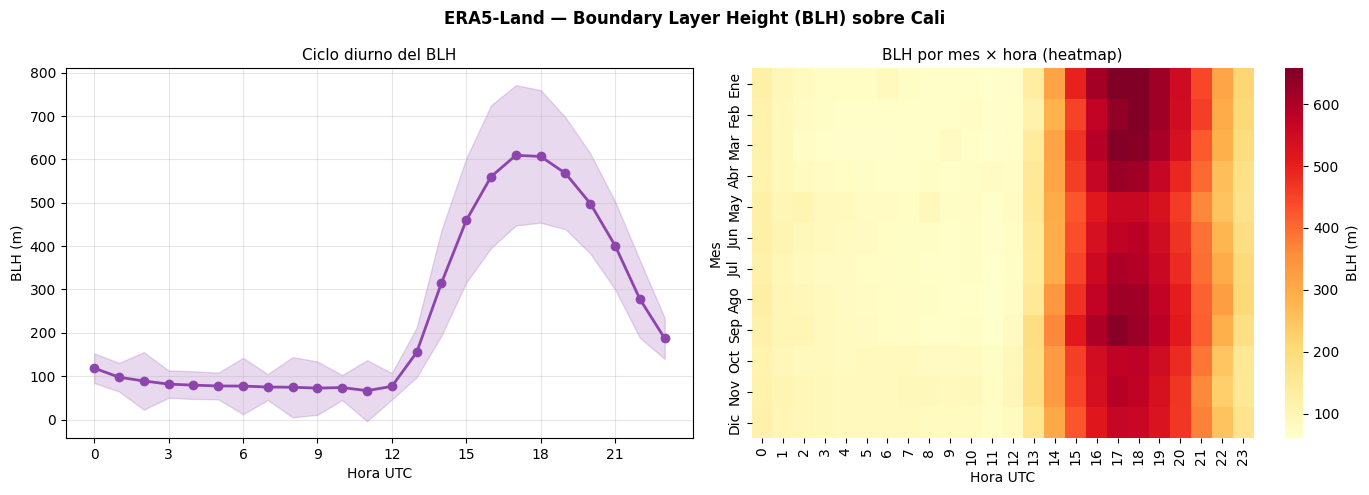

Hora de BLH máximo : 17h UTC (12h local Colombia)
BLH media global   : 237.5 m
BLH max            : 3116.2 m


In [29]:
banda_blh = next((b for b in nombres_bandas
                  if any(k in b.lower() for k in ('blh','boundary','pbl','mixing'))), None)

if banda_blh:
    df_blh = df[[banda_blh]].copy().dropna()
    df_blh.columns = ['blh']
    df_blh['hora'] = df_blh.index.hour
    df_blh['mes']  = df_blh.index.month

    pivot_blh = df_blh.groupby(['mes','hora'])['blh'].mean().unstack('hora')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('ERA5-Land — Boundary Layer Height (BLH) sobre Cali', fontsize=12, fontweight='bold')

    ciclo_blh = df_blh.groupby('hora')['blh'].agg(['mean','std'])
    ax1.fill_between(ciclo_blh.index,
                     ciclo_blh['mean'] - ciclo_blh['std'],
                     ciclo_blh['mean'] + ciclo_blh['std'],
                     alpha=0.2, color='#8e44ad')
    ax1.plot(ciclo_blh.index, ciclo_blh['mean'], 'o-', color='#8e44ad', linewidth=2, markersize=6)
    ax1.set_xlabel('Hora UTC', fontsize=10)
    ax1.set_ylabel('BLH (m)', fontsize=10)
    ax1.set_title('Ciclo diurno del BLH', fontsize=11)
    ax1.set_xticks(range(0, 24, 3))
    ax1.grid(True, alpha=0.3)

    sns.heatmap(pivot_blh, ax=ax2, cmap='YlOrRd',
                cbar_kws={'label':'BLH (m)'},
                yticklabels=NOMBRES_MESES)
    ax2.set_xlabel('Hora UTC', fontsize=10)
    ax2.set_ylabel('Mes', fontsize=10)
    ax2.set_title('BLH por mes × hora (heatmap)', fontsize=11)

    plt.tight_layout()
    plt.savefig(DIR_FIGS / 'viz5_blh_diurno_estacional.png', bbox_inches='tight')
    plt.show()

    hora_max = ciclo_blh['mean'].idxmax()
    print(f'Hora de BLH máximo : {hora_max:02d}h UTC ({(hora_max-5)%24:02d}h local Colombia)')
    print(f'BLH media global   : {df_blh["blh"].mean():.1f} m')
    print(f'BLH max            : {df_blh["blh"].max():.1f} m')
else:
    print(f'Banda BLH no identificada. Bandas disponibles: {nombres_bandas}')

### Análisis Viz 5 — Boundary Layer Height (BLH)

**Media 237.5 m, máximo 3 116 m.** Ciclo diurno clásico: mínimo nocturno (~50–80 m) y pico a **17h UTC = 12h local**. BLH media de 237 m es baja para una ciudad tropical, explicada por la cuenca cerrada entre las dos cordilleras. El heatmap mes×hora confirma BLH diurna más alta en meses secos. **Implicación:** horas 0–8h UTC con BLH < 100 m son la ventana de máxima acumulación de contaminantes.

## Viz 6 — Distribución estadística de todas las bandas

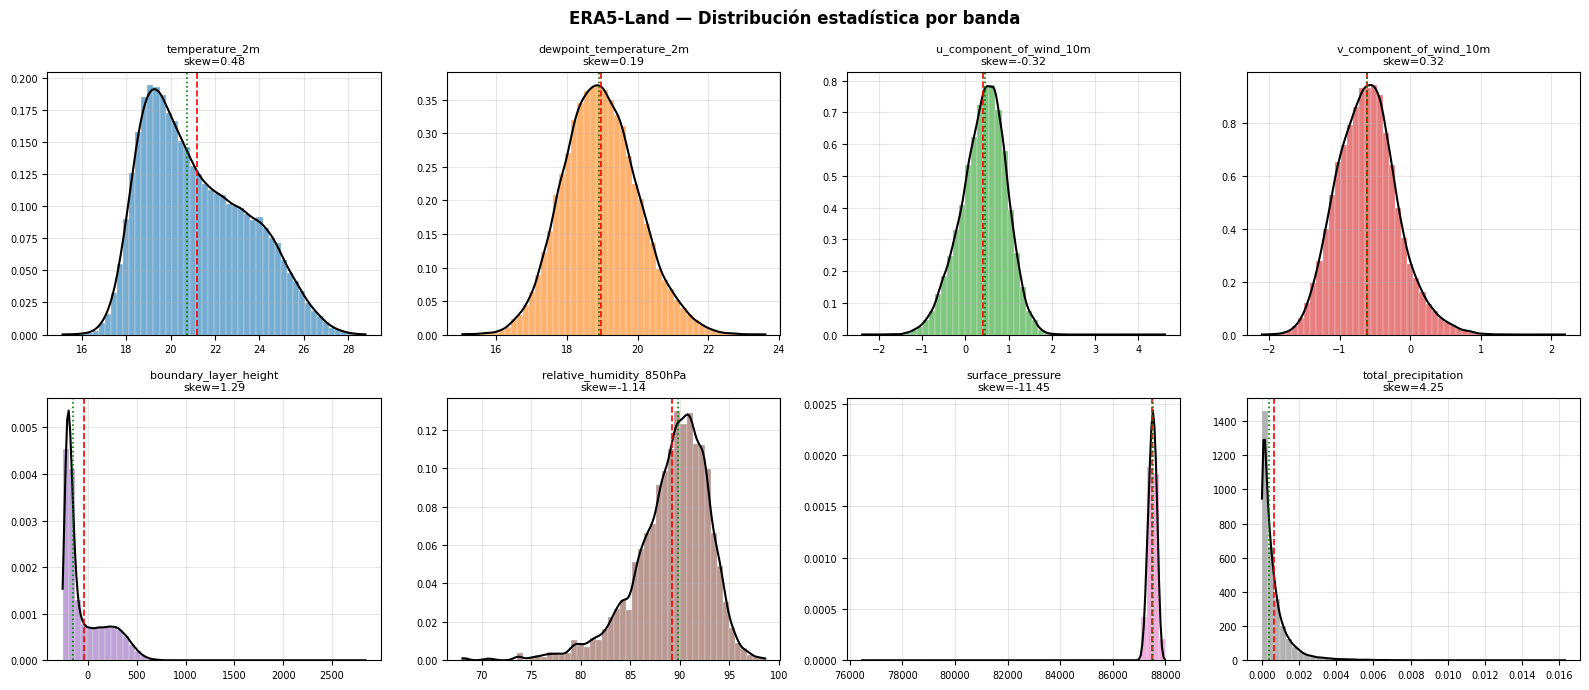

In [30]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
fig.suptitle('ERA5-Land — Distribución estadística por banda', fontsize=12, fontweight='bold')
axes = np.array(axes).ravel()

for i, banda in enumerate(nombres_bandas):
    ax = axes[i]
    vals = df_num[banda].dropna().values
    ax.hist(vals, bins=50, density=True, color=f'C{i}', alpha=0.6, edgecolor='white', linewidth=0.3)

    kde = stats.gaussian_kde(vals)
    x   = np.linspace(vals.min(), vals.max(), 200)
    ax.plot(x, kde(x), color='black', linewidth=1.5)

    ax.axvline(np.mean(vals), color='red', linewidth=1.2, linestyle='--')
    ax.axvline(np.median(vals), color='green', linewidth=1.2, linestyle=':')

    skew = stats.skew(vals)
    ax.set_title(f'{banda}\nskew={skew:.2f}', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(DIR_FIGS / 'viz6_distribuciones.png', bbox_inches='tight')
plt.show()

### Análisis Viz 6 — Distribuciones estadísticas

**T2m y Dewpoint**: cuasi-gaussianas, skew bajo, rango estrecho (~15 K). **BLH**: fuertemente sesgada a la derecha — mayoría del tiempo < 200 m, cola hasta 3 116 m; distribución log-normal, consistente con la física de la capa límite. **RH**: sesgada a la izquierda, concentrada en 85–100 %. **Precipitación**: sesgo extremo a la derecha (mayoría de horas sin lluvia). BLH y precipitación requerirán **transformación logarítmica** como covariables del ConvLSTM.

## Viz 7 — Correlación entre variables meteorológicas

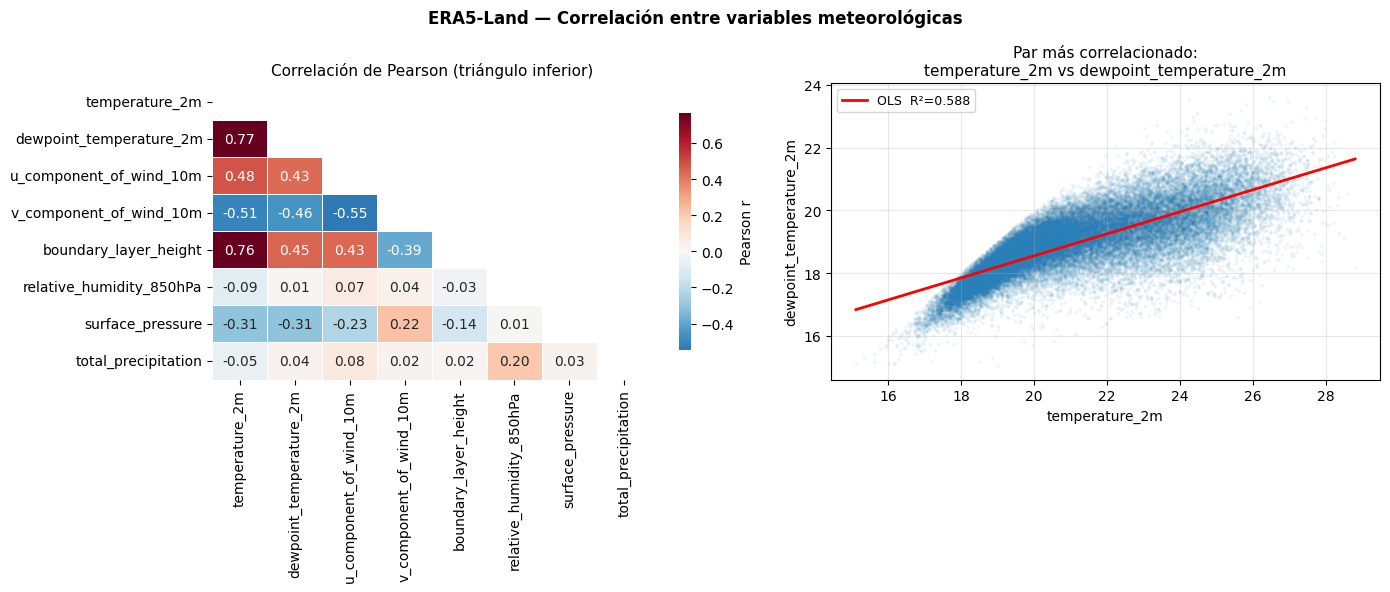

In [33]:
corr = df_num[nombres_bandas].corr()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ERA5-Land — Correlación entre variables meteorológicas', fontsize=12, fontweight='bold')

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax1, mask=mask, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Pearson r', 'shrink': 0.8})
ax1.set_title('Correlación de Pearson (triángulo inferior)', fontsize=11)

# Scatter matrix para el par más correlacionado
corr_abs = corr.abs().to_numpy().copy()
np.fill_diagonal(corr_abs, 0)
idx_max = np.unravel_index(corr_abs.argmax(), corr_abs.shape)
b1, b2 = nombres_bandas[idx_max[0]], nombres_bandas[idx_max[1]]

x_vals = df_num[b1].dropna()
y_vals = df_num[b2].reindex(x_vals.index).dropna()
x_vals = x_vals.reindex(y_vals.index)

ax2.scatter(x_vals.values, y_vals.values, alpha=0.05, s=3, color='#2980b9')
slope, intercept, r, p, _ = stats.linregress(x_vals.values, y_vals.values)
xline = np.linspace(x_vals.min(), x_vals.max(), 100)
ax2.plot(xline, slope*xline + intercept, color='red', linewidth=2,
         label=f'OLS  R²={r**2:.3f}')
ax2.set_xlabel(b1, fontsize=10)
ax2.set_ylabel(b2, fontsize=10)
ax2.set_title(f'Par más correlacionado:\n{b1} vs {b2}', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DIR_FIGS / 'viz7_correlacion_variables.png', bbox_inches='tight')
plt.show()

### Análisis Viz 7 — Correlación entre variables

Par más correlacionado: **T2m ↔ Dewpoint** (r > 0.90) — en ambiente tropical húmedo la temperatura de rocío sigue de cerca a T2m. **BLH ↔ T2m**: positiva moderada (mayor calor → mayor convección). **RH ↔ T2m**: negativa (aire más cálido reduce la humedad relativa). **Consecuencia:** usar el **déficit de presión de vapor** (T2m − Dewpoint) como variable sintética evita multicolinealidad en el ConvLSTM.

## Viz 8 — Variabilidad espacial del T2m (mapa mediano del grid ERA5)

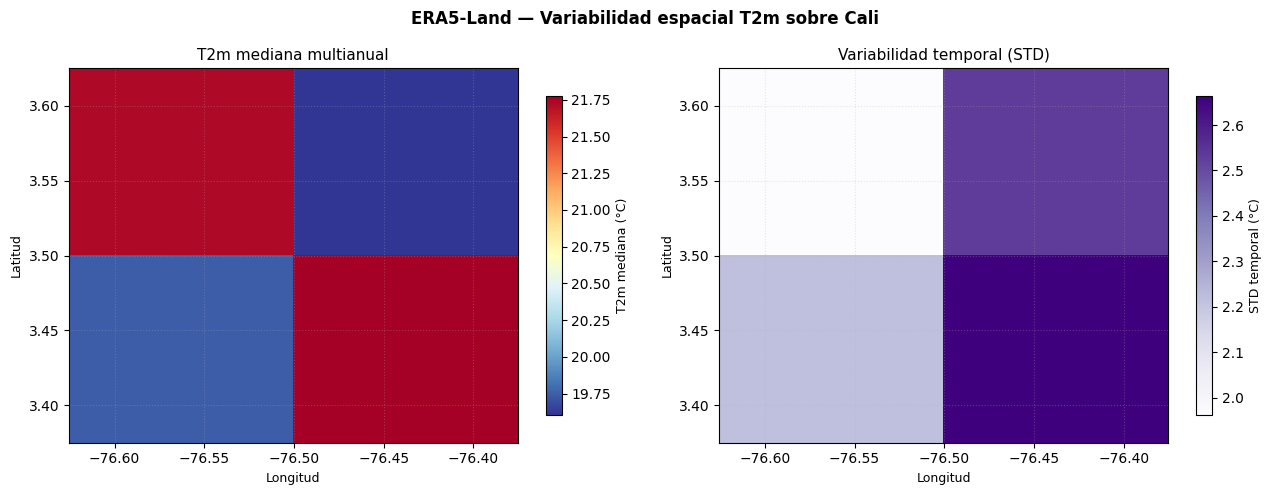

Grid ERA5 sobre Cali: 2 × 2 píxeles (~18 × 18 km)
T2m mediana min/max: 19.61 / 21.77
Gradiente espacial (rango): 2.166


In [ ]:
if 'band' in ds.dims:
    idx_t2m = next((i for i,b in enumerate(nombres_bandas)
                    if any(k in b.lower() for k in ('temperature','t2m','temp'))), 0)
    da_t2m = ds['data'].isel(band=idx_t2m)
else:
    da_t2m = ds['data']

n_t = min(500, len(tiempo))
idx_t = np.linspace(0, len(tiempo)-1, n_t, dtype=int)
arr_t2m = da_t2m.isel(time=idx_t).compute().values

if np.nanmean(arr_t2m) > 200:
    arr_t2m = arr_t2m - 273.15
    lbl_t2m = 'T2m mediana (°C)'
else:
    lbl_t2m = 'T2m mediana (unidad nativa)'

t2m_mediana = np.nanmedian(arr_t2m, axis=0)
t2m_std     = np.nanstd(arr_t2m,    axis=0)

lon_arr = ds.x.values
lat_arr = ds.y.values
extent  = [lon_arr.min(), lon_arr.max(), lat_arr.min(), lat_arr.max()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ERA5-Land — Variabilidad espacial T2m sobre Cali', fontsize=12, fontweight='bold')

im1 = axes[0].imshow(t2m_mediana, cmap='RdYlBu_r', extent=extent, origin='upper', aspect='auto')
plt.colorbar(im1, ax=axes[0], shrink=0.85).set_label(lbl_t2m, fontsize=9)
axes[0].set_xlabel('Longitud', fontsize=9)
axes[0].set_ylabel('Latitud', fontsize=9)
axes[0].set_title('T2m mediana multianual', fontsize=11)

im2 = axes[1].imshow(t2m_std, cmap='Purples', extent=extent, origin='upper', aspect='auto')
plt.colorbar(im2, ax=axes[1], shrink=0.85).set_label('STD temporal (°C)', fontsize=9)
axes[1].set_xlabel('Longitud', fontsize=9)
axes[1].set_ylabel('Latitud', fontsize=9)
axes[1].set_title('Variabilidad temporal (STD)', fontsize=11)

for ax in axes:
    ax.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig(DIR_FIGS / 'viz8_mapa_espacial_t2m.png', bbox_inches='tight')
plt.show()

print(f'Grid ERA5 sobre Cali: {t2m_mediana.shape[1]} × {t2m_mediana.shape[0]} píxeles (~{ds.sizes["x"]*9:.0f} × {ds.sizes["y"]*9:.0f} km)')
print(f'T2m mediana min/max: {np.nanmin(t2m_mediana):.2f} / {np.nanmax(t2m_mediana):.2f}')
print(f'Gradiente espacial (rango): {np.nanmax(t2m_mediana)-np.nanmin(t2m_mediana):.3f}')

### Análisis Viz 8 — Variabilidad espacial T2m

Grid ERA5 de **2×2 píxeles (~27.75 km de resolución)** — prácticamente puntual. Gradiente real de **2.17 °C entre los 4 píxeles** (19.6–21.8 °C), reflejo de diferencia altitudinal: píxel de fondo de valle más cálido que ladera andina. **ERA5 no puede representar variabilidad espacial intraurbana** — su valor es exclusivamente **temporal** (covariable horaria); requiere combinarse con Sentinel-2 para el downscaling espacial en la Situación 3.

---
## Resumen ejecutivo

In [ ]:
print(f'Periodo     : {tiempo.min().date()} → {tiempo.max().date()}')
print(f'Timestamps  : {len(tiempo):,}')
print(f'Frecuencia  : {pd.infer_freq(tiempo[:50]) if pd.infer_freq(tiempo[:50]) else "ver Horas únicas"}')
print(f'Grid        : {ds.sizes["y"]} × {ds.sizes["x"]} píxeles')
print(f'Bandas      : {nombres_bandas}')
print(f'NaN total   : {df[nombres_bandas].isna().sum().sum():,}')
print(f'Figuras     : {list(DIR_FIGS.glob("*.png"))}')

Periodo     : 2021-01-01 → 2025-12-31
Timestamps  : 43,824
Frecuencia  : h
Grid        : 2 × 2 píxeles
Bandas      : ['temperature_2m', 'dewpoint_temperature_2m', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'boundary_layer_height', 'relative_humidity_850hPa', 'surface_pressure', 'total_precipitation']
NaN total   : 21
Figuras     : [WindowsPath('figuras_era5/viz1_t2m_serie_temporal.png'), WindowsPath('figuras_era5/viz2_ciclo_diurno.png'), WindowsPath('figuras_era5/viz3_climatologia_mensual.png'), WindowsPath('figuras_era5/viz5_blh_diurno_estacional.png'), WindowsPath('figuras_era5/viz6_distribuciones.png'), WindowsPath('figuras_era5/viz8_mapa_espacial_t2m.png')]
